# metrics.csv 訓練曲線

讀 `<exp_dir>/train/metrics.csv`,依欄位命名慣例分組(同一種指標、不同層疊在同一張子圖比較)畫出來。

渲染邏輯本身在 `viz/epoch_series.py`(通用,不知道這裡的欄位代表什麼、也不知道哪些欄該疊在一起);
「哪些欄其實是同一種指標、只是不同層」是 `example/metrics_log.py` 特有的欄位命名知識,只在這份 notebook 裡,不進 `viz`。

In [156]:
%matplotlib inline
import os

import matplotlib.pyplot as plt

from example.paths import EXPERIMENTS_DIR
from example.utils import TRAIN_DIRNAME
from viz.epoch_series import EpochSeriesPlot, read_epoch_series_csv

## 參數

改這裡,不改函式庫。

In [157]:
# RUN_NAME = "conv_compressed_compressed_maxsteps_verify_20260914_122946"
RUN_NAME = "conv_compressed_compressed_score_cap_weight_decay_cosine_verify_20260918_085215"
EXP_DIR = EXPERIMENTS_DIR / RUN_NAME  # 絕對路徑,跟 kernel 的工作目錄無關
NCOLS = 4

## 欄位分組

跟 `example/metrics_log.py` 組欄名用的 `f"{name}_{suffix}"` 是同一套字尾——`_METRIC_GROUPS` 就是「哪些欄其實是同一種指標、只是不同層,或同一個資源的容量跟用量」的定義:`event_queue`/`layer_spikes`/`steps` 各自把 `max_*`/`obs_*` 兩欄疊進同一張子圖對照(容量是階梯狀、用量在下面波動)。`decoder_*` 分在一組,其餘(`train_loss`/`val_accuracy`)各自獨立一組。

In [158]:
_METRIC_GROUPS = {
    "firing_rate": ["firing_rate"],
    "grad_norm": ["grad_norm"],
    "dormant_frac": ["dormant_frac"],
    "event_queue": ["max_event_queue", "obs_event_queue"],
    "layer_spikes": ["max_layer_spikes", "obs_layer_spikes"],
    "steps": ["max_steps", "obs_steps"],
}


def group_metrics_columns(columns: list) -> dict:
    """把 metrics.csv 的欄名(不含 epoch)分組:同一個資源(不同層、或同一層的
    容量 vs 用量)分在一組、decoder_* 分在一組,其餘各自獨立一組。回傳的 dict
    保留欄位第一次出現的順序。"""
    groups: dict = {}
    for col in columns:
        if col.startswith("decoder_"):
            groups.setdefault("decoder", []).append(col)
            continue
        matched = next((g for g, suffixes in _METRIC_GROUPS.items()
                        if any(col.endswith("_" + s) for s in suffixes)), None)
        if matched:
            groups.setdefault(matched, []).append(col)
        else:
            groups[col] = [col]
    return groups

## 讀資料、畫圖

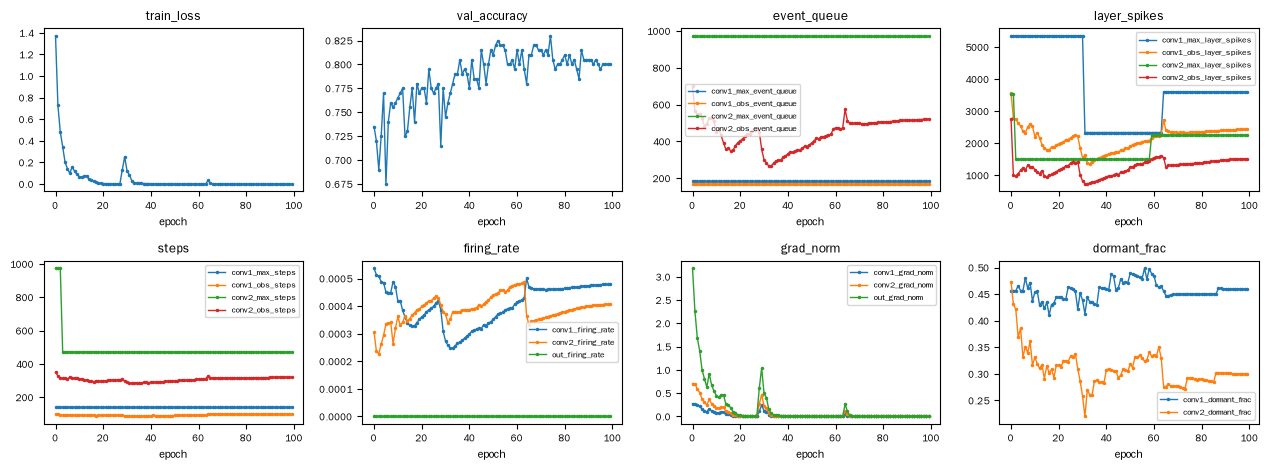

In [159]:
csv_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "metrics.csv")
rows = read_epoch_series_csv(csv_path)
groups = group_metrics_columns([k for k in rows[0].keys() if k != "epoch"])
fig = EpochSeriesPlot(groups=groups, ncols=NCOLS).render(rows)
# fig

## 存檔(選用)

In [160]:
out_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "metrics.png")
fig.savefig(out_path, dpi=150)
print(f"寫入 {out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_score_cap_weight_decay_cosine_verify_20260918_085215/train/metrics.png


## 權重量級(‖W‖)逐 epoch

驗證 docs/問題紀錄.md §十五候選機制表格第一條(輸出無上限 → 曲率無界增長):
逐 epoch 讀 `weights/epoch_XXX.npz` 快照,算每層權重的 Frobenius norm,跟
上面的 loss/val_accuracy 曲線對照時間點。需要 `weight_snapshot_every=1`
(每個 epoch 都存),不是每次跑都有這麼密的快照。

In [161]:
import glob
import re

import numpy as np

from example.models.conv_net import build_network
from example.utils import WEIGHTS_DIRNAME, load_params_npz, load_run_record

run_record = load_run_record(EXP_DIR)
layers = build_network(run_record["config"]["model"])
layer_names = [layer.name for layer in layers]

weights_dir = os.path.join(EXP_DIR, WEIGHTS_DIRNAME)
snapshot_paths = sorted(glob.glob(os.path.join(weights_dir, "epoch_*.npz")))
snapshot_epochs = sorted(int(re.search(r"epoch_(\d+)\.npz", p).group(1)) for p in snapshot_paths)

weight_rows = []
for epoch in snapshot_epochs:
    path = os.path.join(weights_dir, f"epoch_{epoch:03d}.npz")
    params = load_params_npz(path, layers)
    row = {"epoch": epoch}
    for name, w in zip(layer_names, params):
        row[f"{name}_norm"] = float(np.linalg.norm(np.asarray(w)))
    weight_rows.append(row)

print(f"讀到 {len(weight_rows)} 份權重快照(epoch {snapshot_epochs[0]}..{snapshot_epochs[-1]})")

讀到 100 份權重快照(epoch 0..99)


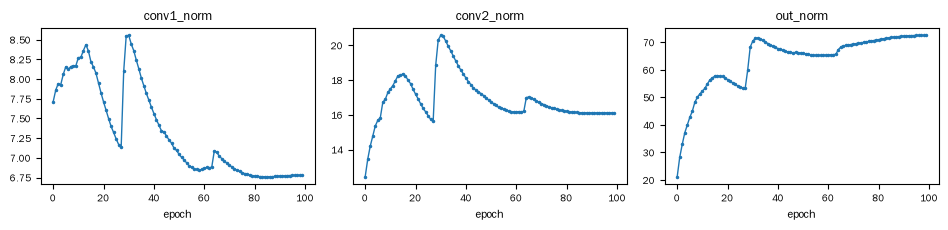

In [162]:
weight_fig = EpochSeriesPlot(ncols=NCOLS).render(weight_rows)
# weight_fig

In [163]:
weight_norm_out_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "weight_norm.png")
weight_fig.savefig(weight_norm_out_path, dpi=150)
print(f"寫入 {weight_norm_out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_score_cap_weight_decay_cosine_verify_20260918_085215/train/weight_norm.png


## 權重步長 $‖θ_{t+1}-θ_t‖$ 逐 epoch

原本 claude 卡在 snn 的二階微分算不了，我在學習過程中知道 
* $e_{t+1, i}' = (1 - lr \cdot \lambda_i) e_{t,i}'$
* $e_t = \theta_t - \theta^*$
* 這說明我們訓練過程中的紀錄 ($\theta$)完全可以拿來用 進而反算 $(1 - lr \cdot \lambda_i)$ 繞開二階微分的問題


驗證候選機制表格第一條的另一種作法:不直接算 Hessian(這個網路的 spike
surrogate gradient 讓二階微分沒有唯一定義,見討論紀錄),改用線性穩定性
分析推出的近似關係 $\Delta\theta_{t+1}/\Delta\theta_t \approx (1-\eta\lambda)$——
連續兩步「實際權重變化量」的比值本身就約等於放大倍率,只需要一階資訊,
不用碰任何二階微分的歧義問題。比值明顯 > 1 的 epoch,就是穩定性被打破的
訊號,應該對得上 loss 爆炸的時間點。

In [164]:
step_rows = []
prev_flat, prev_epoch, prev_norm = None, None, None
for epoch in snapshot_epochs:
    path = os.path.join(weights_dir, f"epoch_{epoch:03d}.npz")
    params = load_params_npz(path, layers)
    flat = np.concatenate([np.asarray(w).ravel() for w in params])
    if prev_flat is not None:
        norm = float(np.linalg.norm(flat - prev_flat))
        # 這才是文件第 6 節真正要驗證的量:(1-ηλ) ≈ step_ratio。第一筆沒有
        # 「前一個 norm」可以除,填 nan(matplotlib/csv 都看得懂,畫圖時該點
        # 自然斷開)。
        ratio = norm / prev_norm if prev_norm is not None else float("nan")
        step_rows.append({"epoch": prev_epoch, "step_norm": norm, "step_ratio": ratio})
        prev_norm = norm
    prev_flat, prev_epoch = flat, epoch

print(f"算出 {len(step_rows)} 個逐 epoch 步長(epoch {step_rows[0]['epoch']}..{step_rows[-1]['epoch']})")

# 光看圖上「有沒有超過 1」不夠,「超過多少」才是訊號——列出實際數字,不用肉眼猜。
ratios = np.array([r["step_ratio"] for r in step_rows if not np.isnan(r["step_ratio"])])
print(f"step_ratio:平均 {ratios.mean():.3f}、標準差 {ratios.std():.3f}、"
      f"中位數 {np.median(ratios):.3f}")

top = sorted((r for r in step_rows if not np.isnan(r["step_ratio"])),
             key=lambda r: r["step_ratio"], reverse=True)[:10]
print("step_ratio 最大的 10 個 epoch(降冪):")
for r in top:
    print(f"  epoch {r['epoch']:>3}: ratio={r['step_ratio']:.3f}")

算出 99 個逐 epoch 步長(epoch 0..98)
step_ratio:平均 1.026、標準差 0.908、中位數 0.905
step_ratio 最大的 10 個 epoch(降冪):
  epoch  27: ratio=9.013
  epoch  63: ratio=4.243
  epoch  46: ratio=1.571
  epoch  23: ratio=1.417
  epoch  43: ratio=1.367
  epoch   6: ratio=1.367
  epoch  60: ratio=1.367
  epoch  62: ratio=1.366
  epoch  26: ratio=1.354
  epoch  44: ratio=1.343


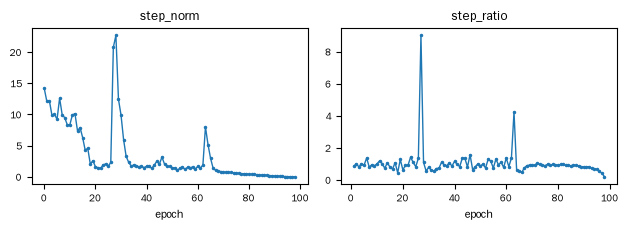

In [165]:
step_fig = EpochSeriesPlot(ncols=NCOLS).render(step_rows)
# step_fig

In [166]:
step_norm_out_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "weight_step_norm.png")
step_fig.savefig(step_norm_out_path, dpi=150)
print(f"寫入 {step_norm_out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_score_cap_weight_decay_cosine_verify_20260918_085215/train/weight_step_norm.png
